# Laboratorio 3 - Parte 1. GMM para clasificación y *clustering*

In [1]:
!wget -nc --no-cache -O init.py -q https://raw.githubusercontent.com/jdariasl/Intro_ML_2025/master/init.py
import init; init.init(force_download=False); init.get_weblink()

In [ ]:
from local.lib.rlxmoocapi import submit, session
import inspect
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L03.01", varname="student");

In [ ]:
student = session.Session(init.endpoint).login(course_id=init.course_id, lab_id='L03.01', google_token=google_token)

In [ ]:
#configuración del laboratorio
# Ejecuta esta celda!
from Labs.commons.utils.lab3 import *
_ = part_1()

## Ejercicio 1: Contextualización del problema

A continuación se leen los datos de un problema de clasificación. El problema corresponde a la clasificación de dígitos escritos a mano. Los datos fueron preprocesados para reducir el número de características y solo se van usar los digitos 0 al 4. La técnica usada para realizar la reducción de dimensión es PCA, la cual ya fue usada en el curso de Modelos y Simulación I, y será nuevamente analizada en detalle más adelante en este curso. Al ejecutar la celda de código, también se podrá visualizar una muestra de los datos usados.

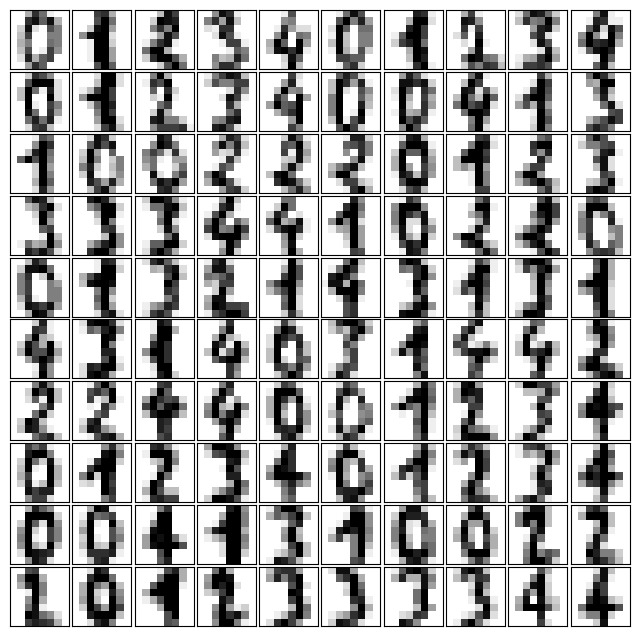

In [ ]:
digits = load_digits(n_class=5)
#--------- preprocesamiento--------------------
pca = PCA(0.99, whiten=True)
data = pca.fit_transform(digits.data)
#---------- Datos a usar ----------------------
x = data[:-1]
y = digits.target[:-1]

plot_digits(digits.data)

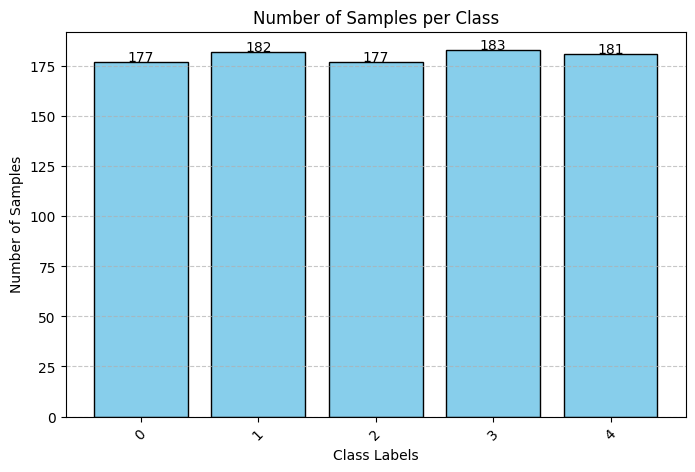

In [ ]:
#Echemos un vistazo a la distribución de las clases
from local.lib.util import plot_samples_per_class
plot_samples_per_class(y)

Para poder realizar la validación de nuestro algoritmo, realizaremos una partición de los datos. Como sabemos, existen dos principales alternativas:
1. [KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html)
2. [ShuffleSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.ShuffleSplit.html)

En el siguiente ejercicio, instancie dos objetos de cada una de las clases de objetos listadas antes. En los dos casos se desea repetir el experimento 4 veces. Cuando instancie los objetos, defina los parámetros para que, aunque las técnicas de validación sean diferentes, los resultados sean estadísticamente equivalentes. Ajuste la semilla de los generadores en 0 para que los resultados sean reproducibles.

In [ ]:
#ejercicio de código
from sklearn.model_selection import KFold
from sklearn.model_selection import ShuffleSplit

def get_cv_objects():
    cv1 = KFold...
    cv2 = ShuffleSplit...
    return cv1, cv2

SyntaxError: invalid syntax (<ipython-input-6-85cdf7f1c69a>, line 2)

In [ ]:
## TEACHER
from local.lib.rlxmoocapi import submit, session
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L03.01", varname="teacher");

logging in as julian.ariasl@udea.edu.co... please wait

-------------
using course session introml::udea.pre.20251
success!! you are logged in
-------------


In [ ]:
teacher = session.Session(init.endpoint).login(course_id=init.course_id, lab_id='L03.01', google_token=google_token)

In [ ]:
## TEACHER DEFINEGRADER
def grader_01(functions, variables, caller_userid):
    import numpy as np
    from sklearn.model_selection import KFold
    from sklearn.model_selection import ShuffleSplit

    cv1_t = KFold(n_splits=4, random_state=0, shuffle=True)
    cv2_t = ShuffleSplit(n_splits=4, test_size=0.2, random_state=0)

    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    s_get_cv_objects = namespace['get_cv_objects']

    cv1_s, cv2_s = s_get_cv_objects()

    msg = "testing your code with 100 random data points<br/>"
    for _ in range(10):
      input_dim = np.random.randint(5)+5
      input_n = np.random.randint(500) + 20
      input_data = np.random.randn(input_n,input_dim)
      output_target = np.random.randn(input_n)


      msg = ""

      # check first model weights
      if cv1_t.n_splits != cv1_s.n_splits:
        msg += f"""
        <b>Incorrect number of folds in KFolds</b>
        Expecting result <pre>{(4,)}</pre> <br/>
        but got <pre>{cv1_s.n_splits}</pre><br/>\n
        """
        return 0, msg

      # check first model weights
      if cv2_t.n_splits != cv2_s.n_splits:
        msg += f"""
        <b>Incorrect number of folds in ShuffleSplit</b>
        Expecting result <pre>{(4,)}</pre> <br/>
        but got <pre>{cv2_s.n_splits}</pre><br/>\n
        """
        return 0, msg

      train_index_1_t, test_index_1_t = next(cv1_t.split(input_data, output_target))
      train_index_2_t, test_index_2_t = next(cv2_t.split(input_data, output_target))
      train_index_1_s, test_index_1_s = next(cv1_s.split(input_data, output_target))
      train_index_2_s, test_index_2_s = next(cv2_s.split(input_data, output_target))

      if len(test_index_2_t) != len(test_index_2_s):
        msg += f"""
        <b>Incorrect number of samples in the partition generated by ShuffleSplit</b>
        Expecting number of training samples <pre>{len(train_index_2_t)}</pre> and testing samples <pre>{len(test_index_2_t)}</pre><br/>
        but got <pre>{len(train_index_2_s)}</pre> and <pre>{len(test_index_2_s)}</pre><br/>\n
        """
        return 0, msg

      if not np.array_equal(train_index_1_t, train_index_1_s):
        msg += f"""
        <b>Incorrect initialization of the partition generated by KFolds</b>
        Expecting training index  <pre>{train_index_1_t}</pre> <br/>
        but got <pre>{train_index_1_s}</pre><br/>\n
        """
        return 0, msg

      if not np.array_equal(test_index_2_t, test_index_2_s):
        msg += f"""
        <b>Incorrect initialization of the partition generated by ShuffleSplit</b>
        Expecting test index  <pre>{test_index_2_t}</pre> <br/>
        but got <pre>{test_index_2_s}</pre><br/>\n
        """
        return 0, msg


      return 5, msg+'<b>correct</b>'
source_functions_names_01 = ['get_cv_objects']
source_variables_names_01 = []

In [ ]:
## TEACHER
from sklearn.model_selection import KFold
from sklearn.model_selection import ShuffleSplit
def get_cv_objects():
    cv1 = KFold(n_splits=4,random_state=0, shuffle=True)
    cv2 = ShuffleSplit(n_splits=4, test_size=0.2, random_state=0)
    return cv1, cv2

In [ ]:
# TEACHER
import inspect
teacher.run_grader_locally("grader_01", source_functions_names_01, source_variables_names_01, locals())

In [ ]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L03.01", 'T1',
                  inspect.getsource(grader_01), 'grader_01',
                  source_functions_names_01, source_variables_names_01)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T1');

## Ejercicio 2: Mezclas de gaussinas

En la siguiente celda vamos a crear una clase para definir un modelo de clasificación basado en el modelo GMM. Para ello vamos a usar la función GaussianMixture de sklearn. Consultar aquí: http://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html

Los parámetros que deben ser tenidos en cuenta para en el entrenamiento del modelo, ya están definidos en el constructor de la clase. Con el propósito de seguir la estructura de los modelos definidos en sklearn, deben completar tres métodos:

- train
- predict
- predict_proba

En el notebook, ya se encuentra cargada la libreria que vamos a usar:

```python
from sklearn.mixture import GaussianMixture
```


In [ ]:
#ejercicio de código
def get_GMM_classifier(n_components,covariance_type,max_iter=100,n_init=5,init_params='kmeans',random_state=0):
  """Función para instanciar un modelo de clasificación basado en Mezclas de Gaussianas
  retorna: objeto de la clase GMMClassifierTrain
  """
  class GMMClassifier():
    def __init__(self, n_components=1, covariance_type='full', max_iter=100, n_init=1, init_params='kmeans', random_state=None):
        self.n_components = n_components
        self.covariance_type = covariance_type
        self.max_iter = max_iter
        self.n_init = n_init
        self.init_params = init_params
        self.random_state = random_state
        self.models = {}
        self.class_labels =[]
    def train(self,X,Y):
      """
      retorna: almacena el diccionario de modelos entrenados y las etiquetas de
      las clases. Las etiquetas de las clases se usan como keys en el diccionario
      """
      ...
      return self

    def predict(self,X):
      """
      retorna: matriz de predicciones de tamaño (n_muestras,)
      """

      self.models = ...
      self.class_labels = ...
      return self

    def predict(self,X):
      """
      retorna: matriz de predicciones de tamaño (n_muestras,)
      """
      ...
      return Yest

    def predict_proba(self,X):
      """
      retorna: matriz de probabilidades de tamaño (n_muestras, n_clases)
      """
      ...
      return Yproba

  return GMMClassifier(
      n_components = n_components,
      covariance_type = covariance_type,
      max_iter = max_iter,
      n_init = n_init,
      init_params=init_params,
      random_state=random_state
      )


In [ ]:
## TEACHER DEFINEGRADER
def grader_02(functions, variables, caller_userid):
    import numpy as np
    from sklearn.mixture import GaussianMixture

    def t_get_GMM_classifier(n_components,covariance_type,max_iter=100,n_init=5,init_params='kmeans',random_state=0):
      """Función para instanciar un modelo de clasificación basado en Mezclas de Gaussianas
      retorna: objeto de la clase GMMClassifierTrain
      """
      class GMMClassifier():
        def __init__(self, n_components=1, covariance_type='full', max_iter=100, n_init=1, init_params='kmeans', random_state=None):
            self.n_components = n_components
            self.covariance_type = covariance_type
            self.max_iter = max_iter
            self.n_init = n_init
            self.init_params = init_params
            self.random_state = random_state
            self.models = {}
            self.class_labels =[]
        def train(self,X,Y):
          self.class_labels = np.unique(Y)
          for label in self.class_labels:
            mask = Y == label
            self.models[label] = GaussianMixture(
                n_components=self.n_components,
                covariance_type=self.covariance_type,
                max_iter=self.max_iter,
                n_init=self.n_init,
                init_params=self.init_params,
                random_state=self.random_state)
            self.models[label].fit(X[mask])
          return self

        def predict(self,X):
          y_pred = []
          for label in self.class_labels:
            y_pred.append(self.models[label].score_samples(X))
          y_pred = np.array(y_pred)
          Yest = np.argmax(y_pred, axis=0)
          return Yest.reshape(-1,1)

        def predict_proba(self,X):
          y_pred = []
          for label in self.class_labels:
            y_pred.append(self.models[label].score_samples(X))
          y_pred = np.array(y_pred).transpose()
          return y_pred/np.sum(y_pred, axis=1)

      return GMMClassifier(
          n_components = n_components,
          covariance_type = covariance_type,
          max_iter = max_iter,
          n_init = n_init,
          init_params=init_params,
          random_state=random_state
          )

    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    s_get_GMM_classifier = namespace['get_GMM_classifier']



    msg = "testing your code with 100 random data points<br/>"
    covariance_types = ['full', 'tied', 'diag', 'spherical']

    for _ in range(10):

      n_components = np.random.randint(3)+1
      covariance_type = np.random.choice(covariance_types)
      max_iter = np.random.randint(100)+1
      n_init = np.random.randint(10)+1


      s_GMM = s_get_GMM_classifier(n_components,covariance_type,max_iter,n_init,init_params='kmeans',random_state=12)
      t_GMM = t_get_GMM_classifier(n_components,covariance_type,max_iter,n_init,init_params='kmeans',random_state=12)


      input_dim = np.random.randint(5)+5
      input_n = np.random.randint(500) + 20
      input_data = np.random.randn(input_n,input_dim)
      n_class = np.random.randint(3)+2
      output_target = np.random.randint(n_class, size=input_n)
      s_GMM.train(input_data,output_target)
      t_GMM.train(input_data,output_target)


      msg = ""
      if not np.array_equal(s_GMM.class_labels, t_GMM.class_labels):
        msg += f"""
        <b>Incorrect identification of class labels</b>
        Expecting class index  <pre>{t_GMM.class_labels}</pre> <br/>
        but got <pre>{s_GMM.class_labels}</pre><br/>\n
        """
        return 0, msg

      if not s_GMM.models[0].n_components == t_GMM.models[0].n_components:
        msg += f"""
        <b>Incorrect number of components</b>
        Expecting number of components <pre>{t_GMM.models[0].n_components}</pre> <br/>
        but got <pre>{s_GMM.models[0].n_components}</pre><br/>\n
        """
        return 0, msg

      if not s_GMM.models[0].n_components == t_GMM.models[1].n_components:

        msg += f"""
        <b>Incorrect number of components</b>
        Expecting number of components <pre>{t_GMM.models[0].n_components}</pre> <br/>
        but got <pre>{s_GMM.models[1].n_components}</pre><br/>\n
        """
        return 0, msg

      if not s_GMM.models[1].covariance_type == t_GMM.models[1].covariance_type:
        msg += f"""
        <b>Incorrect covariance type</b>
        Expecting covariance type <pre>{t_GMM.models[0].covariance_type}</pre> <br/>
        but got <pre>{s_GMM.models[0].covariance_type}</pre><br/>\n
        """
        return 0, msg

      if not np.array_equal(s_GMM.models[0].weights_, t_GMM.models[0].weights_):
        msg += f"""
        <b>Incorrect setting of training hyperparameters</b>
        Expecting component weights for class 0 <pre>{t_GMM.models[0].weights_}</pre> <br/>
        but got <pre>{s_GMM.models[0].weights_}</pre><br/>\n
        """
        return 0, msg

      return 5, msg+'<b>correct</b>'
source_functions_names_02 = ['get_GMM_classifier']
source_variables_names_02 = []

In [ ]:
## TEACHER
def get_GMM_classifier(n_components,covariance_type,max_iter=100,n_init=5,init_params='kmeans',random_state=0):
      """Función para instanciar un modelo de clasificación basado en Mezclas de Gaussianas
      retorna: objeto de la clase GMMClassifierTrain
      """
      class GMMClassifier():
        def __init__(self, n_components=1, covariance_type='full', max_iter=100, n_init=1, init_params='kmeans', random_state=None):
            self.n_components = n_components
            self.covariance_type = covariance_type
            self.max_iter = max_iter
            self.n_init = n_init
            self.init_params = init_params
            self.random_state = random_state
            self.models = {}
            self.class_labels =[]
        def train(self,X,Y):
          self.class_labels = np.unique(Y)
          for label in self.class_labels:
            mask = Y == label
            self.models[label] = GaussianMixture(
                n_components=self.n_components,
                covariance_type=self.covariance_type,
                max_iter=self.max_iter,
                n_init=self.n_init,
                init_params=self.init_params,
                random_state=self.random_state)
            self.models[label].fit(X[mask])
          return self

        def predict(self,X):
          y_pred = []
          for label in self.class_labels:
            y_pred.append(self.models[label].score_samples(X))
          y_pred = np.array(y_pred)
          Yest = np.argmax(y_pred, axis=0)
          return Yest.reshape(-1,1)

        def predict_proba(self,X):
          y_pred = []
          for label in self.class_labels:
            y_pred.append(self.models[label].score_samples(X))
          y_pred = np.array(y_pred).transpose()
          return y_pred/np.sum(y_pred, axis=1)

      return GMMClassifier(
          n_components = n_components,
          covariance_type = covariance_type,
          max_iter = max_iter,
          n_init = n_init,
          init_params=init_params,
          random_state=random_state
          )

In [ ]:
# TEACHER
import inspect
teacher.run_grader_locally("grader_02", source_functions_names_02, source_variables_names_02, locals())

In [ ]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L03.01", 'T2',
                  inspect.getsource(grader_02), 'grader_02',
                  source_functions_names_02, source_variables_names_02)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T2');

NameError: name 'student' is not defined

In [ ]:
#@title Pregunta Abierta
#@markdown En sus palabras, ¿por qué debemos entrenar un modelo por cada clase?
respuesta = "" #@param {type:"string"}

## Ejercicio 3: Experimentos
Con el código completado, vamos a realizar experimentos. Complete la siguiente función para poder obtener los resultados de los experimentos. Tenga en cuenta lo siguiente:
1. Retornar errores de entrenamiento y pruebas
2. Retornar intervalos de confianza (desviacion estandar) para cada una de las configuraciones de hiperparámetros
3. En el código ya se sugiere la metodologia de validación (usando 4 folds) y se incluye, como es usual, el standard scaler para normalizar los datos.

In [ ]:
#ejercicio de código
def experimentar(X, Y, covariance_types,num_components):
    """función que realiza experimentos con el GMM

    X: matriz con las muestras de entrada
    Y: matriz de numpy con las etiquetas de salida
    covariance_types: list[str] con las matrices de covarianza a probar
    num_components: list[int] con el numero de componente a probar

    retorna: dataframe con:
        - matriz de covarianza
        - numero de componentes
        - eficiencia de entrenamiento
        - desviacion de estandar eficiencia de entrenamiento
        - eficiencia de prueba
        - desviacion estandar eficiencia de prueba
    """
    # Definir metodología de validación
    skf, _ = get_cv_objects()
    resultados = pd.DataFrame()
    idx = 0

    for cov_tipo in covariance_types:
        for M in num_components:
            ## para almacenar los errores intermedios
            EficienciaTrain = []
            EficienciaVal = []
            for train, test in skf.split(X, Y):
                Xtrain = X[train,:]
                Ytrain = Y[train]
                Xtest = X[test,:]
                Ytest = Y[test]
                #Normalizamos los datos
                scaler = StandardScaler()
                scaler.fit(Xtrain)
                Xtrain= scaler.transform(Xtrain)
                Xtest = scaler.transform(Xtest)
                #Haga el llamado a la función para crear y entrenar el modelo usando los datos de entrenamiento
                gmms = ...
                #Validación
                Ytrain_pred = ...
                Yest = ...
                #Evaluamos las predicciones del modelo con los datos de test
                EficienciaTrain.append(np.mean(Ytrain_pred.ravel() == Ytrain.ravel()))
                EficienciaVal.append(np.mean(Yest.ravel() == Ytest.ravel()))

            resultados.loc[idx,'matriz de covarianza'] = cov_tipo
            resultados.loc[idx,'numero de componentes'] = M
            resultados.loc[idx,'eficiencia de entrenamiento'] =
            resultados.loc[idx,'desviacion estandar entrenamiento'] =
            resultados.loc[idx,'eficiencia de prueba'] =
            resultados.loc[idx,'desviacion estandar prueba'] =
            idx= idx +1
            print("termina para", cov_tipo, M)

    return (resultados)

In [ ]:
## TEACHER DEFINEGRADER
def grader_03(functions, variables, caller_userid):
    import numpy as np
    from sklearn.mixture import GaussianMixture
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import KFold, ShuffleSplit
    import pandas as pd

    def t_get_GMM_classifier(n_components,covariance_type,max_iter=100,n_init=5,init_params='kmeans',random_state=0):
      """Función para instanciar un modelo de clasificación basado en Mezclas de Gaussianas
      retorna: objeto de la clase GMMClassifierTrain
      """
      class GMMClassifier():
        def __init__(self, n_components=1, covariance_type='full', max_iter=100, n_init=1, init_params='kmeans', random_state=None):
            self.n_components = n_components
            self.covariance_type = covariance_type
            self.max_iter = max_iter
            self.n_init = n_init
            self.init_params = init_params
            self.random_state = random_state
            self.models = {}
            self.class_labels =[]
        def train(self,X,Y):
          self.class_labels = np.unique(Y)
          for label in self.class_labels:
            mask = Y == label
            self.models[label] = GaussianMixture(
                n_components=self.n_components,
                covariance_type=self.covariance_type,
                max_iter=self.max_iter,
                n_init=self.n_init,
                init_params=self.init_params,
                random_state=self.random_state)
            self.models[label].fit(X[mask])
          return self

        def predict(self,X):
          y_pred = []
          for label in self.class_labels:
            y_pred.append(self.models[label].score_samples(X))
          y_pred = np.array(y_pred)
          Yest = np.argmax(y_pred, axis=0)
          return Yest.reshape(-1,1)

        def predict_proba(self,X):
          y_pred = []
          for label in self.class_labels:
            y_pred.append(self.models[label].score_samples(X))
          y_pred = np.array(y_pred).transpose()
          return y_pred/np.sum(y_pred, axis=1)

      return GMMClassifier(
          n_components = n_components,
          covariance_type = covariance_type,
          max_iter = max_iter,
          n_init = n_init,
          init_params=init_params,
          random_state=random_state
          )

    def t_experimentar(X, Y, covariance_types,num_components):
      """función que realiza experimentos con el GMM

      X: matriz con las muestras de entrada
      Y: matriz de numpy con las etiquetas de salida
      covariance_types: list[str] con las matrices de covarianza a probar
      num_components: list[int] con el numero de componente a probar

      retorna: dataframe con:
          - matriz de covarianza
          - numero de componentes
          - eficiencia de entrenamiento
          - desviacion de estandar eficiencia de entrenamiento
          - eficiencia de prueba
          - desviacion estandar eficiencia de prueba
      """
      # Definir metodología de validación
      skf, _ = get_cv_objects()
      resultados = pd.DataFrame()
      idx = 0

      for cov_tipo in covariance_types:
          for M in num_components:
              ## para almacenar los errores intermedios
              EficienciaTrain = []
              EficienciaVal = []

              for train, test in skf.split(X, Y):
                  Xtrain = X[train,:]
                  Ytrain = Y[train]
                  Xtest = X[test,:]
                  Ytest = Y[test]
                  #Normalizamos los datos
                  scaler = StandardScaler()
                  scaler.fit(Xtrain)
                  Xtrain= scaler.transform(Xtrain)
                  Xtest = scaler.transform(Xtest)
                  #Haga el llamado a la función para crear y entrenar el modelo usando los datos de entrenamiento
                  gmms = t_get_GMM_classifier(M,cov_tipo)
                  gmms.train(Xtrain,Ytrain)
                  #Validación
                  Ytrain_pred = gmms.predict(Xtrain)
                  Yest = gmms.predict(Xtest)
                  #Evaluamos las predicciones del modelo con los datos de test
                  EficienciaTrain.append(np.mean(Ytrain_pred.ravel() == Ytrain.ravel()))
                  EficienciaVal.append(np.mean(Yest.ravel() == Ytest.ravel()))
              DesviacionTrain = np.std(EficienciaTrain)
              DesviacionVal = np.std(EficienciaVal)

              resultados.loc[idx,'matriz de covarianza'] = cov_tipo
              resultados.loc[idx,'numero de componentes'] = M
              resultados.loc[idx,'eficiencia de entrenamiento'] = np.mean(np.stack(EficienciaTrain))
              resultados.loc[idx,'desviacion estandar entrenamiento'] = DesviacionTrain
              resultados.loc[idx,'eficiencia de prueba'] = np.mean(np.stack(EficienciaVal))
              resultados.loc[idx,'desviacion estandar prueba'] = DesviacionVal
              idx= idx +1
              print("termina para", cov_tipo, M)

      return (resultados)

    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    s_experimentar = namespace['experimentar']
    get_GMM_classifier = namespace['get_GMM_classifier']
    get_cv_objects = namespace['get_cv_objects']

    msg = "testing your code with 100 random data points<br/>"
    covariance_types = ['full', 'tied', 'diag', 'spherical']

    for _ in range(10):

      input_dim = np.random.randint(5)+5
      input_n = np.random.randint(500) + 20
      input_data = np.random.randn(input_n,input_dim)
      n_class = np.random.randint(3)+2
      output_target = np.random.randint(n_class, size=input_n)

      t_results = t_experimentar(input_data,output_target,covariance_types,[1,2,3,4,5,6])
      s_results = s_experimentar(input_data,output_target,covariance_types,[1,2,3,4,5,6])

      msg = ""
      if not t_results.shape == s_results.shape:
        msg += f"""
        <b>Incorrect number of experiments</b>
        Expecting result shape <pre>{t_results.shape}</pre> <br/>
        but got <pre>{s_results.shape}</pre><br/>\n
        """
        return 0, msg

      if not np.array_equal(t_results.values, s_results.values):
        msg += f"""
        <b>Incorrect results</b>
        Expecting results <pre>{t_results.values}</pre> <br/>
        but got <pre>{s_results.values}</pre><br/>\n
        Check hyperparameter settings
        """
        return 0, msg


      return 5, msg+'<b>correct</b>'
source_functions_names_03 = ['experimentar','get_GMM_classifier','get_cv_objects']
source_variables_names_03 = []

In [ ]:
# TEACHER
def experimentar(X, Y, covariance_types,num_components):
    """función que realiza experimentos con el GMM

    X: matriz con las muestras de entrada
    Y: matriz de numpy con las etiquetas de salida
    covariance_types: list[str] con las matrices de covarianza a probar
    num_components: list[int] con el numero de componente a probar

    retorna: dataframe con:
        - matriz de covarianza
        - numero de componentes
        - eficiencia de entrenamiento
        - desviacion de estandar eficiencia de entrenamiento
        - eficiencia de prueba
        - desviacion estandar eficiencia de prueba
    """
    # Definir metodología de validación
    skf, _ = get_cv_objects()
    resultados = pd.DataFrame()
    idx = 0

    for cov_tipo in covariance_types:
        for M in num_components:
            ## para almacenar los errores intermedios
            EficienciaTrain = []
            EficienciaVal = []

            for train, test in skf.split(X, Y):
                Xtrain = X[train,:]
                Ytrain = Y[train]
                Xtest = X[test,:]
                Ytest = Y[test]
                #Normalizamos los datos
                scaler = StandardScaler()
                scaler.fit(Xtrain)
                Xtrain= scaler.transform(Xtrain)
                Xtest = scaler.transform(Xtest)
                #Haga el llamado a la función para crear y entrenar el modelo usando los datos de entrenamiento
                gmms = get_GMM_classifier(M,cov_tipo)
                gmms.train(Xtrain,Ytrain)
                #Validación
                Ytrain_pred = gmms.predict(Xtrain)
                Yest = gmms.predict(Xtest)
                #Evaluamos las predicciones del modelo con los datos de test
                EficienciaTrain.append(np.mean(Ytrain_pred.ravel() == Ytrain.ravel()))
                EficienciaVal.append(np.mean(Yest.ravel() == Ytest.ravel()))
            DesviacionTrain = np.std(EficienciaTrain)
            DesviacionVal = np.std(EficienciaVal)

            resultados.loc[idx,'matriz de covarianza'] = cov_tipo
            resultados.loc[idx,'numero de componentes'] = M
            resultados.loc[idx,'eficiencia de entrenamiento'] = np.mean(np.stack(EficienciaTrain))
            resultados.loc[idx,'desviacion estandar entrenamiento'] = DesviacionTrain
            resultados.loc[idx,'eficiencia de prueba'] = np.mean(np.stack(EficienciaVal))
            resultados.loc[idx,'desviacion estandar prueba'] = DesviacionVal
            idx= idx +1
            print("termina para", cov_tipo, M)

    return (resultados)

In [ ]:
# TEACHER
import inspect
teacher.run_grader_locally("grader_03", source_functions_names_03, source_variables_names_03, locals())

NameError: name 'teacher' is not defined

In [ ]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L03.01", 'T3',
                  inspect.getsource(grader_03), 'grader_03',
                  source_functions_names_03, source_variables_names_03)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T3');

NameError: name 'student' is not defined

Ahora vamos a ejecutar nuestros experimentos:

In [ ]:
matrices = ['full', 'tied', 'diag', 'spherical']
componentes = [1,2,3]
resultados = experimentar(x, y, matrices, componentes)

termina para full 1
termina para full 2
termina para full 3
termina para tied 1
termina para tied 2
termina para tied 3
termina para diag 1
termina para diag 2
termina para diag 3
termina para spherical 1
termina para spherical 2
termina para spherical 3


In [ ]:
# para ver la tabla
resultados

,matriz de covarianza,numero de componentes,eficiencia de entrenamiento,desviacion estandar entrenamiento,eficiencia de prueba,desviacion estandar prueba
0,full,1.0,1.000000,0.000000,0.993333,0.003849
1,full,2.0,1.000000,0.000000,0.960000,0.013699
2,full,3.0,1.000000,0.000000,0.930000,0.005774
3,tied,1.0,1.000000,0.000000,0.993333,0.003849
4,tied,2.0,1.000000,0.000000,0.993333,0.003849
5,tied,3.0,1.000000,0.000000,0.993333,0.003849
6,diag,1.0,0.987407,0.002222,0.984444,0.008012
7,diag,2.0,0.997778,0.003054,0.987778,0.004843
8,diag,3.0,0.998889,0.001925,0.988889,0.007370
9,spherical,1.0,0.974074,0.001656,0.954444,0.021402


In [ ]:
#@title Pregunta Abierta
#@markdown ¿A qué corresponde el parámetro init_params de la función GaussianMixture y cuál fue el valor usado en nuestros experimentos?
respuesta = "" #@param {type:"string"}

## Ejercicio 4 Kmeans y experimentos

Como sabemos, el modelo GMM puede usarse también para resolver problemas no supervisados. Aunque el dataset que estamos usando contiene etiquetas, vamos a usarlo como si el problema fuera de tipo no supervisado. Usaremos el modelo GMM para resolver el problema y lo compararemos con el algoritmo K-means.

Consultar todo lo relacionado al llamado del método KMeans de la librería scikit-learn en el siguiente enlace: http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html.

En el notebook, ya se encuentra cargada la libreria:

```python
from sklearn.cluster import KMeans
```
Por ello vamos a implementar una función que defina y entre los modelos de clustering KMeans y GMM. Los hiparámetros que se deben usar para instanciar los modelos ya están definidos en la función.



In [ ]:
#ejercicio de código
def entrenar_clustering(numero_clusters,Xtrain,max_iter=100,n_init=5,random_state=0):

  """función que realiza experimentos no supervisados: GMM y Kmeans
  numero_clusters: int número de clusters a usar en los modelos
  Xtrain: matriz con las muestras de entrenamiento

  """
  #Define el modelo de clustering basado en kmeans con el conjunto de hiperparámetros apropiado
  kmeans =
  #¿qué metodo debes llamar para entrenar kmeans?
  kmeans

  # Ahora usa el modelo GMM para hacer clustering (Use matriz de covarianza 'tied')
  gmm = GaussianMixture(...)
  #Entrena el gmm
  gmm
  return  kmeans, gmm

SyntaxError: invalid syntax (<ipython-input-7-f50c0afdab7d>, line 11)

In [ ]:
# TEACHER
def entrenar_clustering(numero_clusters,Xtrain,max_iter=100,n_init=5,random_state=0):

  """función que realiza experimentos no supervisados: GMM y Kmeans
  numero_clusters: int número de clusters a usar en los modelos
  Xtrain: matriz con las muestras de entrenamiento

  """
  #verifica como pasar n_cluster a KMeans
  kmeans = KMeans(n_clusters=numero_clusters, random_state=random_state, n_init=n_init, max_iter=max_iter).fit(Xtrain)
  #¿qué metodo debes llamar para entrenar kmeans?

  # Ahora usa el modelo GMM para hacer clustering (Use matriz de covarianza 'tied')
  gmm = GaussianMixture(n_components=numero_clusters,covariance_type='tied', random_state=random_state, n_init=n_init, max_iter=max_iter).fit(Xtrain)
  #Entrena el gmm
  return  kmeans, gmm

Como sabemos, la evaluación de los algoritmos de agrupamiento no supervisados se hace a partir de medidas que evalúan la cohesión de los grupos encontrados, como el [coeficiente Silhouette](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html). Creemos una función que realice la experimentación para diferente número de grupos de acuerdo con dicha medida.

In [ ]:
#ejercicio de código
from sklearn.metrics import silhouette_score
def experimentar_clustering(numero_clusters,X):
    """función que realiza experimentos no supervisados: GMM y Kmeans
    numero_clusters: list[int] numero cluster para realizar experimentos
    X: matriz con las caractersiticas
    Y: matriz de numpy con etiquetas
    retorna: dataframe con:
        - numero_clusters
        - el error de entrenamiento
        - desviacion de estandar del error entrenamiento
        - error de prueba
        - desviacion estandar eror de prueba
    """
    _, skf = get_cv_objects()
    resultados = pd.DataFrame()
    idx = 0

    for n_cluster in numero_clusters:
        ## para almacenar los errores intermedios
        DesempenoTrain_kmeans = []
        DesempenoVal_kmeans = []
        DesempenoTrain_gmm = []
        DesempenoVal_gmm = []
        EficienciaVal = []
        for train, test in skf.split(X, X):
            Xtrain = X[train,:]
            Xtest = X[test,:]
            #Normalizamos los datos
            scaler = StandardScaler()
            scaler.fit(Xtrain)
            Xtrain= scaler.transform(Xtrain)
            Xtest = scaler.transform(Xtest)

            kmeans, gmm = ...

            #¿Cómo determinar los grupos a los que fueron asignadas las muestras de entrenamiento?
            Gtrain_pred_k = kmeans...
            Gtrain_pred_g = gmm...
            #¿Cómo determinar los grupos a los que fueron asignadas las muestras de prueba?
            Gest_k = kmeans...
            Gest_g = gmm...

            #Evaluamos las predicciones del modelo con los datos de test
            DesempenoTrain_kmeans.append(silhouette_score(Xtrain, Gtrain_pred_k))
            DesempenoVal_kmeans.append(silhouette_score(Xtest, Gest_k))
            DesempenoTrain_gmm.append(silhouette_score(Xtrain, Gtrain_pred_g))
            DesempenoVal_gmm.append(silhouette_score(Xtest, Gest_g))


        resultados.loc[idx,'numero de clusters'] = n_cluster
        resultados.loc[idx,'Silhouette de entrenamiento kmeans'] = np.mean(np.stack(DesempenoTrain_kmeans))
        resultados.loc[idx,'Silhouette de test kmeans'] = np.mean(np.stack(DesempenoVal_kmeans))
        resultados.loc[idx,'Silhouette de entrenamiento gmm'] = np.mean(np.stack(DesempenoTrain_gmm))
        resultados.loc[idx,'Silhouette de test gmm'] = np.mean(np.stack(DesempenoVal_gmm))
        idx= idx +1
        print("termina para", n_cluster)

    return (resultados)

In [ ]:
## TEACHER DEFINEGRADER
def grader_04(functions, variables, caller_userid):
    import numpy as np
    from sklearn.mixture import GaussianMixture
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import KFold, ShuffleSplit
    import pandas as pd
    from sklearn.metrics import silhouette_score

    def t_entrenar_clustering(numero_clusters,Xtrain,max_iter=100,n_init=5,random_state=0):
      """función que realiza experimentos no supervisados: GMM y Kmeans
      numero_clusters: int número de clusters a usar en los modelos
      Xtrain: matriz con las muestras de entrenamiento

      """
      #verifica como pasar n_cluster a KMeans
      kmeans = KMeans(n_clusters=numero_clusters, random_state=random_state, n_init=n_init, max_iter=max_iter).fit(Xtrain)
      #¿qué metodo debes llamar para entrenar kmeans?

      # Ahora usa el modelo GMM para hacer clustering (Use matriz de covarianza tied)
      gmm = GaussianMixture(n_components=numero_clusters,covariance_type='tied', random_state=random_state, n_init=n_init, max_iter=max_iter).fit(Xtrain)
      return  kmeans, gmm

    def t_experimentar_clustering(numero_clusters,X):
        """función que realiza experimentos no supervisados: GMM y Kmeans
        numero_clusters: list[int] numero cluster para realizar experimentos
        X: matriz con las caractersiticas
        Y: matriz de numpy con etiquetas
        retorna: dataframe con:
            - numero_clusters
            - el error de entrenamiento
            - desviacion de estandar del error entrenamiento
            - error de prueba
            - desviacion estandar eror de prueba
        """
        _, skf = get_cv_objects()
        resultados = pd.DataFrame()
        idx = 0

        for n_cluster in numero_clusters:
            ## para almacenar los errores intermedios
            DesempenoTrain_kmeans = []
            DesempenoVal_kmeans = []
            DesempenoTrain_gmm = []
            DesempenoVal_gmm = []
            EficienciaVal = []
            for train, test in skf.split(X, X):
                Xtrain = X[train,:]
                Xtest = X[test,:]
                #Normalizamos los datos
                scaler = StandardScaler()
                scaler.fit(Xtrain)
                Xtrain= scaler.transform(Xtrain)
                Xtest = scaler.transform(Xtest)

                kmeans, gmm = t_entrenar_clustering(n_cluster,Xtrain,max_iter=100,n_init=5,random_state=0)

                #¿Cómo determinar los grupos a los que fueron asignadas las muestras de entrenamiento?
                Gtrain_pred_k = kmeans.predict(Xtrain)
                Gtrain_pred_g = gmm.predict(Xtrain)
                #¿Cómo determinar los grupos a los que fueron asignadas las muestras de prueba?
                Gest_k = kmeans.predict(Xtest)
                Gest_g = gmm.predict(Xtest)

                #Evaluamos las predicciones del modelo con los datos de test
                DesempenoTrain_kmeans.append(silhouette_score(Xtrain, Gtrain_pred_k))
                DesempenoVal_kmeans.append(silhouette_score(Xtest, Gest_k))
                DesempenoTrain_gmm.append(silhouette_score(Xtrain, Gtrain_pred_g))
                DesempenoVal_gmm.append(silhouette_score(Xtest, Gest_g))


            resultados.loc[idx,'numero de clusters'] = n_cluster
            resultados.loc[idx,'Silhouette de entrenamiento kmeans'] = np.mean(np.stack(DesempenoTrain_kmeans))
            resultados.loc[idx,'Silhouette de test kmeans'] = np.mean(np.stack(DesempenoVal_kmeans))
            resultados.loc[idx,'Silhouette de entrenamiento gmm'] = np.mean(np.stack(DesempenoTrain_gmm))
            resultados.loc[idx,'Silhouette de test gmm'] = np.mean(np.stack(DesempenoVal_gmm))
            idx= idx +1
            print("termina para", n_cluster)

        return (resultados)


    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    s_experimentar_clustering = namespace['experimentar_clustering']
    entrenar_clustering = namespace['entrenar_clustering']
    get_cv_objects = namespace['get_cv_objects']

    msg = "testing your code with 100 random data points<br/>"
    covariance_types = ['full', 'tied', 'diag', 'spherical']

    for _ in range(2):

      input_dim = np.random.randint(5)+5
      input_n = np.random.randint(500) + 20
      input_data = np.random.randn(input_n,input_dim)
      numero_clusters = np.random.randint(3)+2

      t_kmeans, t_gmm = t_entrenar_clustering(numero_clusters,input_data,max_iter=200,n_init=4,random_state=10)
      s_kmeans, s_gmm = entrenar_clustering(numero_clusters,input_data,max_iter=200,n_init=4,random_state=10)

      msg = ""
      if t_kmeans.n_clusters !=  s_kmeans.n_clusters:
        msg += f"""
        <b>Incorrect number of clusters in kmeans</b>
        Expecting <pre>{numero_clusters}</pre> <br/>
        but got <pre>{s_kmeans.n_cluster}</pre><br/>\n
        """
        return 0, msg

      if t_gmm.n_components !=  s_gmm.n_components:
        msg += f"""
        <b>Incorrect number of components in gmm</b>
        Expecting <pre>{numero_clusters}</pre> <br/>
        but got <pre>{s_gmm.n_components}</pre><br/>\n
        """
        return 0, msg

      if not np.allclose(t_kmeans.cluster_centers_,s_kmeans.cluster_centers_):
        msg += f"""
        <b>Incorrect cluster centers in kmeans</b>
        Expecting <pre>{t_kmeans.cluster_centers_}</pre> <br/>
        but got <pre>{s_kmeans.cluster_centers_}</pre><br/>\n
        """
        return 0, msg

      if not np.allclose(t_gmm.means_,s_gmm.means_):
        msg += f"""
        <b>Incorrect means in gmm</b>
        Expecting <pre>{t_gmm.means_}</pre> <br/>
        but got <pre>{s_gmm.means_}</pre><br/>\n
        """
        return 0, msg

      t_results = t_experimentar_clustering([2,3,4,5,6],input_data)
      s_results = s_experimentar_clustering([2,3,4,5,6],input_data)

      msg = ""
      if not t_results.shape == s_results.shape:
        msg += f"""
        <b>Incorrect number of experiments</b>
        Expecting result shape <pre>{t_results.shape}</pre> <br/>
        but got <pre>{s_results.shape}</pre><br/>\n
        """
        return 0, msg

      if not np.array_equal(t_results.values, s_results.values):
        msg += f"""
        <b>Incorrect results</b>
        Expecting results <pre>{t_results.values}</pre> <br/>
        but got <pre>{s_results.values}</pre><br/>\n
        Check hyperparameter settings
        """
        return 0, msg


    return 5, msg+'<b>correct</b>'
source_functions_names_04 = ['experimentar_clustering','entrenar_clustering','get_cv_objects']
source_variables_names_04 = []

In [ ]:
# TEACHER
from sklearn.metrics import silhouette_score
def experimentar_clustering(numero_clusters,X):
    """función que realiza experimentos no supervisados: GMM y Kmeans
    numero_clusters: list[int] numero cluster para realizar experimentos
    X: matriz con las caractersiticas
    Y: matriz de numpy con etiquetas
    retorna: dataframe con:
        - numero_clusters
        - el error de entrenamiento
        - desviacion de estandar del error entrenamiento
        - error de prueba
        - desviacion estandar eror de prueba
    """
    _, skf = get_cv_objects()
    resultados = pd.DataFrame()
    idx = 0

    for n_cluster in numero_clusters:
        ## para almacenar los errores intermedios
        DesempenoTrain_kmeans = []
        DesempenoVal_kmeans = []
        DesempenoTrain_gmm = []
        DesempenoVal_gmm = []
        EficienciaVal = []
        for train, test in skf.split(X, X):
            Xtrain = X[train,:]
            Xtest = X[test,:]
            #Normalizamos los datos
            scaler = StandardScaler()
            scaler.fit(Xtrain)
            Xtrain= scaler.transform(Xtrain)
            Xtest = scaler.transform(Xtest)

            kmeans, gmm = entrenar_clustering(n_cluster,Xtrain,max_iter=100,n_init=5,random_state=0)

            #¿Cómo determinar los grupos a los que fueron asignadas las muestras de entrenamiento?
            Gtrain_pred_k = kmeans.predict(Xtrain)
            Gtrain_pred_g = gmm.predict(Xtrain)
            #¿Cómo determinar los grupos a los que fueron asignadas las muestras de prueba?
            Gest_k = kmeans.predict(Xtest)
            Gest_g = gmm.predict(Xtest)

            #Evaluamos las predicciones del modelo con los datos de test
            DesempenoTrain_kmeans.append(silhouette_score(Xtrain, Gtrain_pred_k))
            DesempenoVal_kmeans.append(silhouette_score(Xtest, Gest_k))
            DesempenoTrain_gmm.append(silhouette_score(Xtrain, Gtrain_pred_g))
            DesempenoVal_gmm.append(silhouette_score(Xtest, Gest_g))


        resultados.loc[idx,'numero de clusters'] = n_cluster
        resultados.loc[idx,'Silhouette de entrenamiento kmeans'] = np.mean(np.stack(DesempenoTrain_kmeans))
        resultados.loc[idx,'Silhouette de test kmeans'] = np.mean(np.stack(DesempenoVal_kmeans))
        resultados.loc[idx,'Silhouette de entrenamiento gmm'] = np.mean(np.stack(DesempenoTrain_gmm))
        resultados.loc[idx,'Silhouette de test gmm'] = np.mean(np.stack(DesempenoVal_gmm))
        idx= idx +1
        print("termina para", n_cluster)

    return (resultados)

In [ ]:
# TEACHER
import inspect
teacher.run_grader_locally("grader_04", source_functions_names_04, source_variables_names_04, locals())

termina para 2
termina para 3
termina para 4
termina para 5
termina para 6
termina para 2
termina para 3
termina para 4
termina para 5
termina para 6
termina para 2
termina para 3
termina para 4
termina para 5
termina para 6
termina para 2
termina para 3
termina para 4
termina para 5
termina para 6
termina para 2
termina para 3
termina para 4
termina para 5
termina para 6
termina para 2
termina para 3
termina para 4
termina para 5
termina para 6
termina para 2
termina para 3
termina para 4
termina para 5
termina para 6
termina para 2
termina para 3
termina para 4
termina para 5
termina para 6
termina para 2
termina para 3
termina para 4
termina para 5
termina para 6
termina para 2
termina para 3
termina para 4
termina para 5
termina para 6
termina para 2
termina para 3
termina para 4
termina para 5
termina para 6
termina para 2
termina para 3
termina para 4
termina para 5
termina para 6
termina para 2
termina para 3
termina para 4
termina para 5
termina para 6
termina para 2
termina pa

In [ ]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L03.01", 'T4',
                  inspect.getsource(grader_04), 'grader_04',
                  source_functions_names_04, source_variables_names_04)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T4');

In [ ]:
# ejecuta los experimentos y ve los resultados
resultados_clustering = experimentar_clustering([3,5,6,8],x)
resultados_clustering

termina para 3
termina para 5
termina para 6
termina para 8


,numero de clusters,Silhouette de entrenamiento kmeans,Silhouette de test kmeans,Silhouette de entrenamiento gmm,Silhouette de test gmm
0,3.0,0.027844,0.019032,0.026568,0.026529
1,5.0,0.027423,0.018486,0.027480,0.022297
2,6.0,0.027132,0.026483,0.031028,0.019538
3,8.0,0.041697,0.022609,0.036641,0.010104


In [ ]:
#@title Pregunta Abierta
#@markdown ¿Qué método podría usar para determinar el grado de pertenencia de una muestra a cada grupo según el modelo GMM ?
respuesta = "" #@param {type:"string"}

In [ ]:
#@title Pregunta Abierta
#@markdown ¿Es el número de grupos óptimo coherente con el número de clases en el problema?
respuesta = "" #@param {type:"string"}

Teniendo en cuenta que los métodos que hemos usados son no supervisados, el orden asignado a los grupos no tiene porqué coincidir con las etiquetas de clase. Vamos a graficar los centroides de las clases para ver con cuál de las clases coinciden.

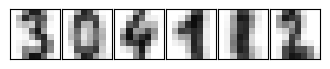

In [ ]:
# ejercicio de código

n_cluster = ... #Escoja un número de clusters de acuerdo con el resultado anterior
_, skf = get_cv_objects()
train, test = next(skf.split(x, x))
Xtrain = x[train,:]
Xtest = x[test,:]

#Normalizamos los datos
scaler = StandardScaler()
scaler.fit(Xtrain)
Xtrain= scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

modelo = ....fit(Xtrain) #Seleccione uno de los dos modelos de clustering
centroids = pca.inverse_transform(....) #Extraiga los centroides del modelo y haga la transformación inversa de PCA

fig, ax = plt.subplots(1, n_cluster, figsize=(4, 8),subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for i, axi in enumerate(ax.flat):
    im = axi.imshow(centroids[i].reshape(8, 8), cmap='binary')
    im.set_clim(0, 16)


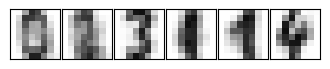

In [ ]:
# TEACHER

n_cluster = 6 #Escoja un número de clusters de acuerdo con el resultado anterior
_, skf = get_cv_objects()
train, test = next(skf.split(x, x))
Xtrain = x[train,:]
Xtest = x[test,:]

#Normalizamos los datos
scaler = StandardScaler()
scaler.fit(Xtrain)
Xtrain= scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

modelo = KMeans(n_clusters=n_cluster).fit(Xtrain) #Seleccione uno de los dos modelos de clustering
centroids = pca.inverse_transform(modelo.cluster_centers_) #Extraiga los centroides del modelo y haga la transformación inversa de PCA

fig, ax = plt.subplots(1, n_cluster, figsize=(4, 8),subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for i, axi in enumerate(ax.flat):
    im = axi.imshow(centroids[i].reshape(8, 8), cmap='binary')
    im.set_clim(0, 16)

In [ ]:
#@title Pregunta Abierta
#@markdown ¿Corresponden los centroides a las clases del problema?
respuesta = "" #@param {type:"string"}

In [3]:
## TEACHER
# --- CREATE or OVERWRITE STUDENTS NOTEBOOK ---
import init
from local.lib.rlxmoocapi import utils
student_notebook_fname = utils.convert_this_notebook_to_student()

<IPython.core.display.Javascript object>

NOTEBOOK name is lab3_parte1--XX--TEACHER--XX.ipynb
student notebook writen to 'lab3_parte1.ipynb'
